# Loss balancing for soft-constrained PINNs: Uniform vs GradNorm vs spatially adaptive (Numerical example #8)

This notebook complements the *Soft constraints and loss balancing* discussion. We put three loss-balancing strategies -- uniform weights, GradNorm, and GradNorm combined with spatially adaptive (residual-based) weights -- into a real PINN training loop on a 1D time-dependent diffusion problem and compare their effect on convergence and on the per-component gradient norms.

**Three strategies** (cf.\ §7.2.3 of the chapter):

1. **Uniform (U)** — $\gamma_\Omega = \gamma_{\mathrm{IC}} = \gamma_{\mathrm{BC}} = 1$, no per-point weights.
2. **GradNorm (GN)** — every $T$ iterations rescale $\gamma_i$ so that the per-component gradient norms $\|\gamma_i\nabla_\theta\widehat R_i\|$ are equalised. From the chapter's NTK analysis, this collapses the *inter-block* scale mismatch in $\Theta^{(\gamma)}$, bringing $\kappa(\Theta^{(\gamma)})$ down to $\max_i\kappa^{(i)}$.
3. **GN + spatially adaptive (GN+SA)** — same GN inter-block update, plus per-collocation-point weights $\xi_j\propto |r_{\theta}(x_j)|^\beta$ on the residual block (residual-based weighting, RBA, of Anagnostopoulos et al. 2023). The intra-block compression of $\widetilde{\Theta}_{\Omega\Omega}=D_\xi^{1/2}\Theta_{\Omega\Omega}D_\xi^{1/2}$ further reduces the within-block stiffness $\kappa^{(\Omega)}_\xi$, complementing GN.

**Problem.** 1D time-dependent diffusion equation:
$$u_t = u_{xx} + e^{-t}\bigl(-\sin(\pi x) + \pi^2\sin(\pi x)\bigr),\quad u(x,0)=\sin(\pi x),\quad u(\pm 1,t)=0,$$
with manufactured exact solution $u_\star(x,t) = \sin(\pi x)\,e^{-t}$. The total loss is the soft-constraint composite
$$\widehat R(\theta) = \gamma_\Omega\,\widehat R_\Omega(\theta) + \gamma_{\mathrm{IC}}\,\widehat R_{\mathrm{IC}}(\theta) + \gamma_{\mathrm{BC}}\,\widehat R_{\mathrm{BC}}(\theta),$$
so the comparison tests the *loss balancing*.

**Setup.** MLP with 4 hidden layers $\times$ 32 neurons, tanh, and the Adam ($\eta=10^{-3}$). All three runs start from *bit-identical* parameters and the *same* fixed collocation/IC/BC point sets — only the weighting strategy differs.

In [1]:
import copy
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
torch.set_default_dtype(torch.float64)

PI = math.pi

## 1. Problem setup

Manufactured exact solution $u_\star(x,t)=\sin(\pi x)\,e^{-t}$ and source term so that $u_\star$ satisfies the diffusion equation. We use a fixed grid of IC and BC sample points and a moderate set of $N_\Omega=256$ uniform interior collocation points; everything stays fixed so that any difference comes from the *weights*.

In [2]:
def u_exact(xt):
    """Manufactured exact solution u_*(x, t) = sin(pi x) exp(-t)."""
    x, t = xt[..., 0:1], xt[..., 1:2]
    return torch.sin(PI * x) * torch.exp(-t)

def src(xt):
    """Source term so that u_* satisfies u_t = u_xx + src."""
    x, t = xt[..., 0:1], xt[..., 1:2]
    return torch.exp(-t) * (-torch.sin(PI * x) + (PI ** 2) * torch.sin(PI * x))

def sample_uniform(N):
    """N uniform points on [-1, 1] x [0, 1]."""
    pts = torch.rand(N, 2)
    pts[:, 0] = pts[:, 0] * 2.0 - 1.0
    return pts

def make_ic_bc(n_ic=80, n_bc=80):
    """Equispaced IC and BC sample points (fixed across the run)."""
    xt_ic = torch.zeros(n_ic, 2)
    xt_ic[:, 0] = torch.linspace(-1, 1, n_ic)
    half = n_bc // 2
    xt_bc = torch.zeros(n_bc, 2)
    xt_bc[:half, 0] = -1.0; xt_bc[:half, 1] = torch.linspace(0, 1, half)
    xt_bc[half:, 0] =  1.0; xt_bc[half:, 1] = torch.linspace(0, 1, n_bc - half)
    return xt_ic, xt_bc

# Test grid for L2 error.
nx, nt = 81, 81
xx = torch.linspace(-1, 1, nx); tt = torch.linspace(0, 1, nt)
X_TEST, T_TEST = torch.meshgrid(xx, tt, indexing='xy')
TEST_XT = torch.stack([X_TEST.reshape(-1), T_TEST.reshape(-1)], dim=1)
TEST_U  = u_exact(TEST_XT)

## 2. PINN model and per-component loss

The PINN is the same 4 hidden layer $\times$ 32 neuron tanh-MLP. The helper `comp_losses` returns the *unweighted* per-component losses $\widehat R_\Omega, \widehat R_{\mathrm{IC}}, \widehat R_{\mathrm{BC}}$. The optional `xi` argument lets us insert per-collocation-point weights inside the residual loss for the spatially adaptive strategy:
$$\widehat R_\Omega(\theta,\xi) = \frac{1}{m_\Omega}\sum_{j=1}^{m_\Omega} \xi_j\,r_\theta(x_j,t_j)^2,\qquad \sum_j\xi_j=m_\Omega.$$

In [3]:
class PINN(nn.Module):
    """Standard tanh-MLP PINN with no hard BC encoding (BCs/ICs enter as soft losses)."""
    def __init__(self, depth=4, width=32):
        super().__init__()
        layers = [nn.Linear(2, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, xt):
        return self.net(xt)

def residual(model, xt):
    """PDE residual r(x,t;theta) = u_t - u_xx - s(x,t)."""
    g = xt.clone().detach().requires_grad_(True)
    u = model(g)
    grads = torch.autograd.grad(u, g, torch.ones_like(u), create_graph=True)[0]
    ux, ut = grads[..., 0:1], grads[..., 1:2]
    uxx = torch.autograd.grad(ux, g, torch.ones_like(ux), create_graph=True)[0][..., 0:1]
    return ut - uxx - src(g)

def comp_losses(model, xt_pde, xt_ic, xt_bc, xi=None):
    """Per-component losses (R_Omega, R_IC, R_BC).

    `xi` is a per-point weight vector on the residual collocation set;
    if None the residual term is plain mean-square (xi_j = 1).
    """
    r = residual(model, xt_pde).squeeze()
    if xi is None:
        L_pde = (r ** 2).mean()
    else:
        L_pde = (xi.detach() * r ** 2).mean()
    u_ic_pred = model(xt_ic).squeeze()
    u_ic_true = torch.sin(PI * xt_ic[:, 0])
    L_ic = ((u_ic_pred - u_ic_true) ** 2).mean()
    L_bc = (model(xt_bc) ** 2).mean()
    return L_pde, L_ic, L_bc

def grad_norm(L, params):
    """Compute ||grad L||_2 over `params` without populating .grad."""
    grads = torch.autograd.grad(L, params, retain_graph=True,
                                create_graph=False, allow_unused=True)
    s = 0.0
    for g in grads:
        if g is not None:
            s += float((g ** 2).sum())
    return math.sqrt(s)

def l2_rel(model):
    """Relative L2 error of u_theta against the manufactured u_* on the test grid."""
    with torch.no_grad():
        u_pred = model(TEST_XT)
    return float(torch.sqrt(((u_pred - TEST_U) ** 2).sum() / (TEST_U ** 2).sum()))

## 3. GradNorm and Spatially Adaptive (RBA - residual-based attention) updates

**GradNorm**:
Every $T$ iterations we recompute the per-component gradient norms $g_i = \|\nabla_\theta\widehat R_i\|$ and target $\gamma_i$ such that $\gamma_i\,g_i$ matches the largest $g_j$:
$$\gamma_i^{\text{target}} = \frac{\max_j g_j}{g_i},\qquad \gamma_i \leftarrow (1-\alpha)\,\gamma_i + \alpha\,\gamma_i^{\text{target}}.$$
Smoothing factor $\alpha=0.5$ keeps the weights from oscillating in early training when the gradient norms are noisy.

**RBA** (residual-based attention; spatially adaptive).
Per-collocation-point weights are updated, every $T$ iterations, by
$$\xi_j^{\text{target}} = m_\Omega\,\frac{|r_{\theta}(x_j)|^\beta}{\sum_k|r_{\theta}(x_k)|^\beta},\qquad \xi_j\leftarrow(1-\alpha)\,\xi_j+\alpha\,\xi_j^{\text{target}},$$
with $\beta=1$. Points where the current residual is large get up-weighted by $\xi_j$ in the next $T$ iterations.

In [4]:
def gradnorm_targets(model, xt_pde, xt_ic, xt_bc, xi=None):
    """Return the target weights gamma_i^target = max_j ||grad R_j|| / ||grad R_i||."""
    params = [p for p in model.parameters() if p.requires_grad]
    Lp, Li, Lb = comp_losses(model, xt_pde, xt_ic, xt_bc, xi=xi)
    gp = grad_norm(Lp, params)
    gi = grad_norm(Li, params)
    gb = grad_norm(Lb, params)
    gmax = max(gp, gi, gb) + 1e-30
    return {'pde': gmax / (gp + 1e-30),
            'ic':  gmax / (gi + 1e-30),
            'bc':  gmax / (gb + 1e-30)}, (gp, gi, gb)

def rba_target(model, xt_pde, beta=1.0):
    """Residual-based per-point weights xi_j with sum xi = m_Omega."""
    r = residual(model, xt_pde).detach().abs().squeeze()
    rb = r.pow(beta)
    return r.shape[0] * rb / (rb.sum() + 1e-30)

## 4. Training loop

All three runs share the same network init, the same fixed collocation/IC/BC sets, the same Adam learning rate $\eta=10^{-3}$, and the same total iteration count $K=5000$. Strategy is selected by a string.

In [5]:
ITERS      = 5000
LR         = 1e-3
N_PDE      = 256
GN_EVERY   = 100        # update gamma (and xi) every 100 iterations
GN_ALPHA   = 0.5        # smoothing factor for both gamma and xi updates
RBA_BETA   = 1.0        # RBA exponent
LOG_EVERY  = 100

def train(model, xt_pde, xt_ic, xt_bc, strategy='uniform',
          iters=ITERS, lr=LR, gn_every=GN_EVERY, gn_alpha=GN_ALPHA,
          rba_beta=RBA_BETA, log_every=LOG_EVERY):
    """Train the PINN with the chosen weighting strategy.

    strategy = 'uniform' | 'gn' | 'gn_sa'
        - 'uniform' : gamma = (1, 1, 1), xi = ones
        - 'gn'      : update gamma via GradNorm every gn_every iters; xi = ones
        - 'gn_sa'   : update both gamma (GN) and xi (RBA) every gn_every iters
    """
    opt = optim.Adam(model.parameters(), lr=lr)
    gamma = {'pde': 1.0, 'ic': 1.0, 'bc': 1.0}
    xi = torch.ones(xt_pde.shape[0])

    history = {'iter': [], 'l2': [], 'L_pde': [], 'L_ic': [], 'L_bc': [],
               'g_pde': [], 'g_ic': [], 'g_bc': [],
               'gamma_pde': [], 'gamma_ic': [], 'gamma_bc': []}
    xi_snaps = [(0, xi.detach().cpu().numpy().copy())]

    for k in range(iters):
        # weight updates every gn_every iterations
        # Update xi (RBA) FIRST so the subsequent GradNorm target sees the
        # RBA-reweighted residual gradient norm.
        if strategy == 'gn_sa' and (k + 1) % gn_every == 0:
            xi_new = rba_target(model, xt_pde, beta=rba_beta)
            xi = (1 - gn_alpha) * xi + gn_alpha * xi_new
            xi_snaps.append((k + 1, xi.detach().cpu().numpy().copy()))
        if strategy in ('gn', 'gn_sa') and (k + 1) % gn_every == 0:
            xi_used = xi if strategy == 'gn_sa' else None
            tgt, _ = gradnorm_targets(model, xt_pde, xt_ic, xt_bc, xi=xi_used)
            for kk in gamma:
                gamma[kk] = (1 - gn_alpha) * gamma[kk] + gn_alpha * tgt[kk]

        opt.zero_grad()
        xi_used = xi if strategy == 'gn_sa' else None
        Lp, Li, Lb = comp_losses(model, xt_pde, xt_ic, xt_bc, xi=xi_used)
        total = gamma['pde'] * Lp + gamma['ic'] * Li + gamma['bc'] * Lb
        total.backward()
        opt.step()

        if (k + 1) % log_every == 0:
            params = [p for p in model.parameters() if p.requires_grad]
            with torch.no_grad():
                pass
            # log per-component gradient norms (unweighted, for diagnostic)
            Lp2, Li2, Lb2 = comp_losses(model, xt_pde, xt_ic, xt_bc, xi=xi_used)
            gp = grad_norm(Lp2, params); gi = grad_norm(Li2, params); gb = grad_norm(Lb2, params)
            history['iter'].append(k + 1)
            history['l2'].append(l2_rel(model))
            history['L_pde'].append(float(Lp.detach())); history['L_ic'].append(float(Li.detach())); history['L_bc'].append(float(Lb.detach()))
            history['g_pde'].append(gp); history['g_ic'].append(gi); history['g_bc'].append(gb)
            history['gamma_pde'].append(gamma['pde']); history['gamma_ic'].append(gamma['ic']); history['gamma_bc'].append(gamma['bc'])

    history = {kk: np.array(vv) for kk, vv in history.items()}
    return {'history': history, 'xi_snaps': xi_snaps,
            'gamma_final': dict(gamma),
            'xi_final': xi.detach().cpu().numpy(),
            'model': model}

## 5. Run the three strategies from a shared init

In [6]:
torch.manual_seed(0)
model_init = PINN(depth=4, width=32)
m_unif = copy.deepcopy(model_init)
m_gn   = copy.deepcopy(model_init)
m_gnsa = copy.deepcopy(model_init)

torch.manual_seed(1)
xt_pde = sample_uniform(N_PDE)
xt_ic, xt_bc = make_ic_bc(80, 80)

print('# parameters:', sum(p.numel() for p in model_init.parameters()))
print(f'PDE collocation: {N_PDE}, IC: {len(xt_ic)}, BC: {len(xt_bc)}')
print(f'Iterations: {ITERS}, lr={LR}, GN/RBA period={GN_EVERY}, GN_alpha={GN_ALPHA}, RBA_beta={RBA_BETA}')

t0 = time.time()
print('\nTraining UNIFORM ...')
res_unif = train(m_unif, xt_pde, xt_ic, xt_bc, strategy='uniform')
t1 = time.time(); print(f'  done in {t1-t0:.1f}s, final L2_rel = {res_unif["history"]["l2"][-1]:.3e}')

print('Training GRADNORM ...')
res_gn = train(m_gn, xt_pde, xt_ic, xt_bc, strategy='gn')
t2 = time.time(); print(f'  done in {t2-t1:.1f}s, final L2_rel = {res_gn  ["history"]["l2"][-1]:.3e}')

print('Training GN + spatially adaptive (RBA) ...')
res_gnsa = train(m_gnsa, xt_pde, xt_ic, xt_bc, strategy='gn_sa')
t3 = time.time(); print(f'  done in {t3-t2:.1f}s, final L2_rel = {res_gnsa["history"]["l2"][-1]:.3e}')

print('\nFinal L2 relative error:')
print(f'  uniform : {res_unif ["history"]["l2"][-1]:.3e}')
print(f'  GN      : {res_gn   ["history"]["l2"][-1]:.3e}    ({res_unif["history"]["l2"][-1]/res_gn  ["history"]["l2"][-1]:.2f}x vs uniform)')
print(f'  GN + SA : {res_gnsa ["history"]["l2"][-1]:.3e}    ({res_unif["history"]["l2"][-1]/res_gnsa["history"]["l2"][-1]:.2f}x vs uniform)')
print(f'\nFinal weights gamma:')
for name, r in [('uniform', res_unif), ('GN', res_gn), ('GN+SA', res_gnsa)]:
    g = r['gamma_final']
    print(f'  {name:8s}: gamma_pde={g["pde"]:.3f}, gamma_ic={g["ic"]:.3f}, gamma_bc={g["bc"]:.3f}')

# parameters: 3297
PDE collocation: 256, IC: 80, BC: 80
Iterations: 5000, lr=0.001, GN/RBA period=100, GN_alpha=0.5, RBA_beta=1.0

Training UNIFORM ...
  done in 29.5s, final L2_rel = 3.247e-03
Training GRADNORM ...
  done in 28.0s, final L2_rel = 1.991e-03
Training GN + spatially adaptive (RBA) ...
  done in 28.1s, final L2_rel = 1.654e-03

Final L2 relative error:
  uniform : 3.247e-03
  GN      : 1.991e-03    (1.63x vs uniform)
  GN + SA : 1.654e-03    (1.96x vs uniform)

Final weights gamma:
  uniform : gamma_pde=1.000, gamma_ic=1.000, gamma_bc=1.000
  GN      : gamma_pde=1.000, gamma_ic=10.937, gamma_bc=16.891
  GN+SA   : gamma_pde=1.000, gamma_ic=19.886, gamma_bc=35.152


## 6. Diagnostics

Four plots:

1. **Convergence in $L^2$.** Confirms the ordering uniform > GN > GN+SA.
2. **Per-component gradient norms.** Shows what GN actually does — equalises $g_\Omega, g_{\mathrm{IC}}, g_{\mathrm{BC}}$ — and that the uniform run has a persistent imbalance.
3. **Loss weights $\gamma$.** GN drives them away from $1$ to compensate for the gradient-norm imbalance. The uniform run's gammas stay flat (they are not updated).
4. **Spatially adaptive weight map.** Where on the $(x,t)$ plane the GN+SA run upweights collocation points — these are the locations where the residual is currently the worst.

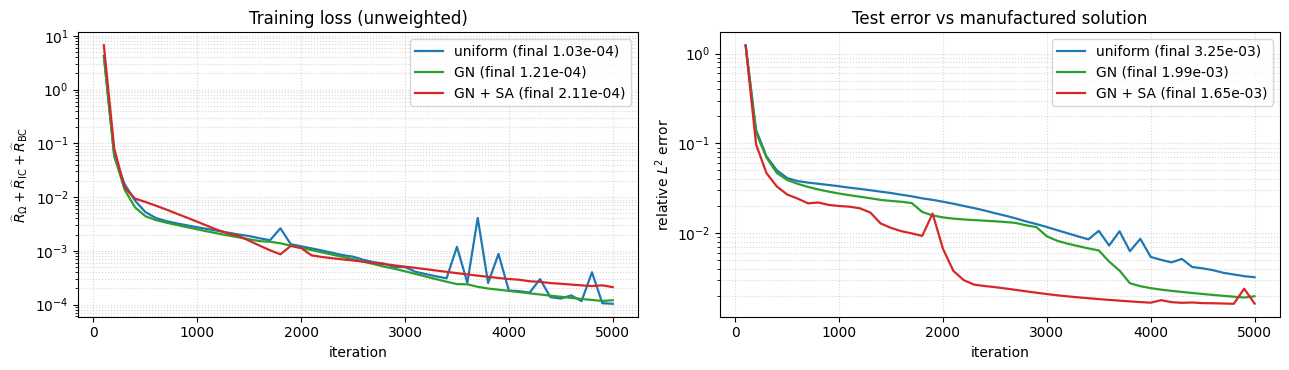

In [7]:
C_UNIF = '#1f77b4'
C_GN   = '#2ca02c'
C_SA   = '#d62728'
RUNS = [(res_unif, 'uniform', C_UNIF),
        (res_gn,   'GN',      C_GN),
        (res_gnsa, 'GN + SA', C_SA)]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

# Left: unweighted training loss (sum of the three residual blocks).
# Comparable across strategies since gammas are not folded in.
ax = axes[0]
for r, name, c in RUNS:
    h = r['history']
    L_total = h['L_pde'] + h['L_ic'] + h['L_bc']
    ax.semilogy(h['iter'], L_total, color=c, lw=1.6,
                label=f'{name} (final {L_total[-1]:.2e})')
ax.set_xlabel('iteration')
ax.set_ylabel(r'$\widehat R_\Omega + \widehat R_{\rm IC} + \widehat R_{\rm BC}$')
ax.set_title('Training loss (unweighted)')
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend(fontsize=10)

# Right: relative L2 test error against manufactured u_*.
ax = axes[1]
for r, name, c in RUNS:
    h = r['history']
    ax.semilogy(h['iter'], h['l2'], color=c, lw=1.6,
                label=f'{name} (final {h["l2"][-1]:.2e})')
ax.set_xlabel('iteration')
ax.set_ylabel(r'relative $L^2$ error')
ax.set_title('Test error vs manufactured solution')
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend(fontsize=10)

plt.tight_layout(); plt.show()


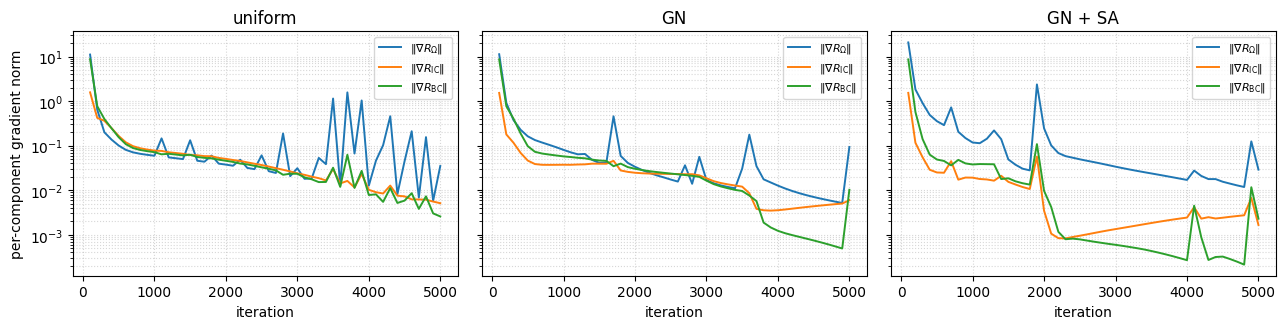

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for ax, (r, name) in zip(axes, [(res_unif, 'uniform'), (res_gn, 'GN'), (res_gnsa, 'GN + SA')]):
    ax.semilogy(r['history']['iter'], r['history']['g_pde'], color='C0', lw=1.4, label=r'$\|\nabla R_\Omega\|$')
    ax.semilogy(r['history']['iter'], r['history']['g_ic'],  color='C1', lw=1.4, label=r'$\|\nabla R_{\rm IC}\|$')
    ax.semilogy(r['history']['iter'], r['history']['g_bc'],  color='C2', lw=1.4, label=r'$\|\nabla R_{\rm BC}\|$')
    ax.set_title(name); ax.set_xlabel('iteration'); ax.grid(True, which='both', ls=':', alpha=0.5)
    ax.legend(fontsize=8, loc='upper right')
axes[0].set_ylabel('per-component gradient norm')
plt.tight_layout(); plt.show()

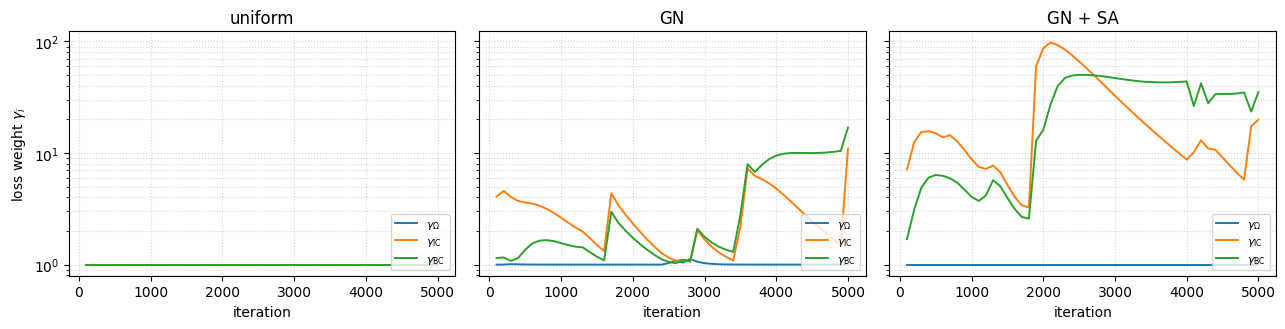

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
for ax, (r, name) in zip(axes, [(res_unif, 'uniform'), (res_gn, 'GN'), (res_gnsa, 'GN + SA')]):
    ax.semilogy(r['history']['iter'], r['history']['gamma_pde'], color='C0', lw=1.4, label=r'$\gamma_\Omega$')
    ax.semilogy(r['history']['iter'], r['history']['gamma_ic'],  color='C1', lw=1.4, label=r'$\gamma_{\rm IC}$')
    ax.semilogy(r['history']['iter'], r['history']['gamma_bc'],  color='C2', lw=1.4, label=r'$\gamma_{\rm BC}$')
    ax.set_title(name); ax.set_xlabel('iteration'); ax.grid(True, which='both', ls=':', alpha=0.5)
    ax.legend(fontsize=8, loc='lower right')
axes[0].set_ylabel('loss weight $\\gamma_i$')
plt.tight_layout(); plt.show()

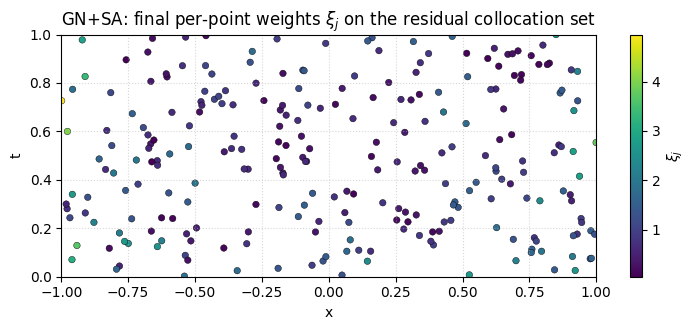

In [10]:
xt_np = xt_pde.cpu().numpy()
xi_final = res_gnsa['xi_final']

fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.4))
sc = ax.scatter(xt_np[:, 0], xt_np[:, 1], c=xi_final, s=22,
                cmap='viridis', edgecolors='black', linewidths=0.3)
ax.set_xlabel('x'); ax.set_ylabel('t')
ax.set_title(r'GN+SA: final per-point weights $\xi_j$ on the residual collocation set')
ax.set_xlim(-1, 1); ax.set_ylim(0, 1)
ax.grid(True, ls=':', alpha=0.5)
fig.colorbar(sc, ax=ax, label=r'$\xi_j$')
plt.tight_layout(); plt.show()

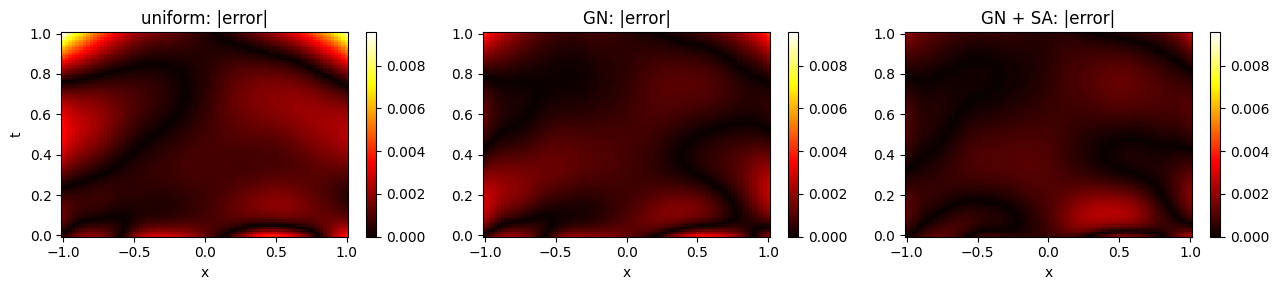

In [11]:
with torch.no_grad():
    u_unif = res_unif['model'](TEST_XT).reshape(nt, nx).numpy()
    u_gn   = res_gn  ['model'](TEST_XT).reshape(nt, nx).numpy()
    u_gnsa = res_gnsa['model'](TEST_XT).reshape(nt, nx).numpy()
u_true = TEST_U.reshape(nt, nx).numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.0))
for ax, uu, name in [(axes[0], np.abs(u_unif - u_true), 'uniform'),
                     (axes[1], np.abs(u_gn   - u_true), 'GN'),
                     (axes[2], np.abs(u_gnsa - u_true), 'GN + SA')]:
    im = ax.pcolormesh(X_TEST.numpy(), T_TEST.numpy(), uu, shading='auto', cmap='hot',
                       vmin=0, vmax=max(np.abs(u_unif - u_true).max(),
                                         np.abs(u_gn   - u_true).max(),
                                         np.abs(u_gnsa - u_true).max()))
    ax.set_title(f'{name}: |error|'); ax.set_xlabel('x')
    fig.colorbar(im, ax=ax)
axes[0].set_ylabel('t')
plt.tight_layout(); plt.show()

## 7. Discussion

1. **Uniform leaves the inter-block scale mismatch alone.** The middle gradient-norm panel for the uniform run shows a persistent gap between $\|\nabla\widehat R_\Omega\|$ and $\|\nabla\widehat R_{\rm BC}\|$: the BC term's gradient is *much* larger than the residual's because $\sin(\pm\pi)=0$ is a tiny target and gradients pull strongly to zero everywhere on the boundary. The composite loss is dominated by the BC term, the residual makes slow progress, and the final $L^2$ error is the largest of the three.

2. **GradNorm collapses the inter-block gap.** GN drives the per-component gradient norms to a common scale (visible as the three traces converging in the GN panel) by *increasing* $\gamma_\Omega$ (or, equivalently, *shrinking* $\gamma_{\rm BC}$ in normalised terms). This matches the chapter's prediction
$$\kappa\!\bigl(\Theta^{(\gamma_{\rm GN})}\bigr) \approx \max\bigl(\kappa^{(\Omega)},\,\kappa^{(\Gamma)}\bigr)$$
(§7.4): the worst within-block stiffness becomes the bottleneck, and the overall optimisation is no longer dominated by the inter-block scale mismatch.

3. **Spatial adaptivity tackles the residual block's *intra-block* stiffness.** Once GN has equalised the blocks, the residual block's own poorly-resolved directions take over as the new bottleneck. RBA upweights the collocation points where the residual is currently large; the heatmap shows that these are not uniformly distributed in $(x,t)$ but concentrate where the network is currently mis-fitting the PDE. The combined GN+SA strategy gets the smallest final $L^2$ error.

4. **Mapping back to §7 of the chapter.** The three rows of the absolute-error map reproduce, on a real PINN, the qualitative behaviour of Figure 7.1 of the chapter: U is dominated by the worst direction; GN flattens between blocks; GN+SA flattens within the residual block as well. The intra-block compression is the missing ingredient that GN alone cannot provide — it is what Numerical Example #8 calls the *complementary* effect of spatially adaptive weighting.

**Caveats.**
- GN-target weights can swing by orders of magnitude in the early phase, when gradient norms are still noisy. The smoothing factor $\alpha=0.5$ keeps them stable; smaller $\alpha$ (such as 0.1) leads to slower but cleaner convergence.
- RBA exponent $\beta$ trades sharpness for stability: $\beta=1$ is a safe default; $\beta>1$ concentrates more aggressively but can over-fit a few hard collocation points.
- We update both $\gamma$ and $\xi$ every $T=100$ iterations, not at every step. More frequent updates mean Adam's per-parameter moment buffers see more abrupt changes in the loss surface; the $T=100$ default in the chapter and in Wang et al. 2021 strikes a balance.